#PERSIAPAN LIBRARY

In [28]:
# @title Install kagglehub & mount Google Drive
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [1]:
!pip install -q kagglehub

In [2]:
# @title Import Library

import os
import random

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

sns.set_style("whitegrid")


def set_seed(seed: int = 42):
    """Set semua random seed agar hasil reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {DEVICE}")

Menggunakan device: cuda


In [3]:
import glob
import shutil

#DOWNLOAD DATASET

In [4]:
# @title Kaggle Helper Function
def download_kaggle_dataset(dataset_id, is_competition=False):
    fn = (
        kagglehub.competition_download if is_competition else kagglehub.dataset_download
    )
    path = fn(dataset_id)
    print("Path to dataset:")
    print(path)
    print("Dataset's folders & files:")
    !ls "{path}"
    return path

In [5]:
# @title APTOS 2019 (Original)
aptos_org_path = download_kaggle_dataset(
    "aptos2019-blindness-detection", is_competition=True
)

# struktur dataset ini: <aptos_org_path>/train.csv + <aptos_org_path>/train_images/<id_code>.png
# struktur csv ini: "id_code" dan "diagnosis"

100%|██████████| 9.51G/9.51G [01:14<00:00, 137MB/s]

Extracting files...


Path to dataset:
/root/.cache/kagglehub/competitions/aptos2019-blindness-detection
Dataset's folders & files:
sample_submission.csv  test.csv  test_images  train.csv  train_images


In [4]:
# @title APTOS 2019 (224x224)
aptos_224_path = download_kaggle_dataset(
    "sovitrath/diabetic-retinopathy-224x224-2019-data"
)

# struktur dataset ini: <aptos_224_path>/train.csv + <aptos_224_path>/colored_images/<kelas>/<id_code>.png
# struktur csv ini: "id_code" dan "diagnosis"

100%|██████████| 238M/238M [00:12<00:00, 19.9MB/s]

Extracting files...


Path to dataset:
/root/.cache/kagglehub/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/versions/4
Dataset's folders & files:
colored_images	train.csv


In [6]:
# @title Dataset Lokal (Google Drive ke disk lokal Colab)
LOCAL_DR_DIR_DRIVE = "/content/drive/MyDrive/BayesianCNN/Dataset/Lokal"
LOCAL_DR_DIR = "/content/data/local_raw"


def copy_drive_to_local(src_dir, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    all_files = [
        f
        for f in glob.glob(os.path.join(src_dir, "**", "*"), recursive=True)
        if os.path.isfile(f)
    ]
    copied, skipped = 0, 0
    for src_fp in tqdm(all_files, desc="Copy Drive -> lokal Colab"):
        rel_path = os.path.relpath(src_fp, src_dir)
        dst_fp = os.path.join(dst_dir, rel_path)
        os.makedirs(os.path.dirname(dst_fp), exist_ok=True)
        if os.path.exists(dst_fp) and os.path.getsize(dst_fp) == os.path.getsize(
            src_fp
        ):
            skipped += 1
            continue
        shutil.copy2(src_fp, dst_fp)
        copied += 1
    print(
        f"Selesai copy: {copied} file baru, {skipped} file sudah ada (di-skip, idempotent kalau re-run)."
    )


copy_drive_to_local(LOCAL_DR_DIR_DRIVE, LOCAL_DR_DIR)

print("Isi folder lokal:")
for cls in ["No_DR", "Mild", "Moderate", "Severe", "Proliferate_DR"]:
    n = len(glob.glob(os.path.join(LOCAL_DR_DIR, cls, "*")))
    print(f"  {cls}: {n} file")

Copy Drive -> lokal Colab:   0%|          | 0/351 [00:00<?, ?it/s]

Selesai copy: 351 file baru, 0 file sudah ada (di-skip, idempotent kalau re-run).
Isi folder lokal:
  No_DR: 41 file
  Mild: 29 file
  Moderate: 59 file
  Severe: 67 file
  Proliferate_DR: 155 file


#BUILD DATAFRAME UNTUK SETIAP DATASET

In [6]:
# @title Dataframe Helper Functions
LABEL_NAMES = ["No_DR", "Mild", "Moderate", "Severe", "Proliferate_DR"]
LABEL_MAP = dict(enumerate(LABEL_NAMES))
CLASS_ALIASES = {
    "No_DR": ["No_DR", "0"],
    "Mild": ["Mild", "1"],
    "Moderate": ["Moderate", "2"],
    "Severe": ["Severe", "3"],
    "Proliferate_DR": ["Proliferate_DR", "4"],
}


def resolve_image_path(base_path, extensions=(".jpg", ".jpeg", ".png")):
    if os.path.exists(base_path):
        return base_path
    for ext in extensions:
        if os.path.exists(base_path + ext):
            return base_path + ext
    return None


def load_csv_labeled_df(
    csv_path,
    img_dir,
    id_col,
    label_col,
    source_name,
    filename_suffix="",
    label_map=LABEL_MAP,
    extensions=(".jpg", ".jpeg", ".png"),
):
    meta = pd.read_csv(csv_path)
    rows = []
    for _, row in meta.iterrows():
        base_path = os.path.join(img_dir, f"{row[id_col]}{filename_suffix}")
        img_path = resolve_image_path(base_path, extensions)
        if img_path and row[label_col] in label_map:
            rows.append(
                {
                    "filepath": img_path,
                    "label": label_map[row[label_col]],
                    "source": source_name,
                }
            )
    df = pd.DataFrame(rows)
    df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)
    print(f"[{source_name}] valid: {len(df)}")
    print(df["label"].value_counts())
    print("\n")
    return df


def load_class_folder_df(
    root_dir,
    source_name,
    class_aliases=CLASS_ALIASES,
    extensions=(".png", ".jpg", ".jpeg"),
):
    rows = []
    for label, aliases in class_aliases.items():
        folder_path = next(
            (
                os.path.join(root_dir, a)
                for a in aliases
                if os.path.isdir(os.path.join(root_dir, a))
            ),
            None,
        )
        if folder_path is None:
            continue
        rows += [
            {"filepath": fp, "label": label, "source": source_name}
            for fp in glob.glob(os.path.join(folder_path, "*"))
            if fp.lower().endswith(extensions)
        ]
    df = pd.DataFrame(rows)
    df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)
    print(f"[{source_name}]")
    print(df["label"].value_counts().sort_index())
    print("\n")
    return df

In [7]:
# @title Load DF Dataset APTOS Original (struktur csv_labeled)
aptos_org_df = load_csv_labeled_df(
    csv_path=os.path.join(aptos_org_path, "train.csv"),
    img_dir=os.path.join(aptos_org_path, "train_images"),
    id_col="id_code",
    label_col="diagnosis",
    source_name="aptos-org",
)

[aptos-org] valid: 3662
label
No_DR             1805
Moderate           999
Mild               370
Proliferate_DR     295
Severe             193
Name: count, dtype: int64




In [9]:
# @title Load DF Dataset APTOS 224 + Lokal (struktur class_folders)
aptos_224_df = load_class_folder_df(
    root_dir=os.path.join(aptos_224_path, "colored_images"), source_name="aptos-224"
)

local_df = load_class_folder_df(root_dir=LOCAL_DR_DIR, source_name="local")

[aptos-224]
label
Mild               370
Moderate           999
No_DR             1805
Proliferate_DR     295
Severe             193
Name: count, dtype: int64




#GABUNGKAN DATASET (OPSIONAL)

In [8]:
def build_combined_dataset(dfs: dict[str, pd.DataFrame], seed=42):
    full_df = pd.concat(dfs.values(), ignore_index=True)
    before = len(full_df)
    full_df = full_df[full_df["filepath"].apply(os.path.exists)].reset_index(drop=True)
    print(f"Total baris (combined): {before} | Valid files: {len(full_df)}")
    full_df = full_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    print(full_df["label"].value_counts().sort_index())
    return full_df


full_df = build_combined_dataset(
    {
        "aptos-org": aptos_org_df,
        # "local": local_df,
        # "aptos-224": aptos_224_df
    }
)

Total baris (combined): 3662 | Valid files: 3662
label
Mild               370
Moderate           999
No_DR             1805
Proliferate_DR     295
Severe             193
Name: count, dtype: int64


#IMAGE PREPROCESSOR

In [9]:
# @title Preprocessing BEN (Brightness Enhancement Normalization) - Revised

import cv2

cv2.setNumThreads(0)


def crop_image_from_gray(img_rgb, crop_thresh=7, min_crop_dim=10):
    """
    Crop area gelap (uninformative) menggunakan mask grayscale yang
    diterapkan konsisten ke SEMUA channel sekaligus (bukan per-channel
    terpisah, yang bisa membuat R/G/B tidak selaras).
    Ada fallback aman: jika gambar terlalu gelap sehingga hasil crop
    kosong/terlalu kecil, kembalikan gambar asli — mencegah error
    dimensi-0 saat inference pada gambar adversarial/sangat gelap.
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    mask = gray > crop_thresh

    if not np.any(mask):
        return img_rgb  # gambar terlalu gelap, jangan di-crop

    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1  # +1 karena slicing eksklusif di ujung atas

    if (y1 - y0) < min_crop_dim or (x1 - x0) < min_crop_dim:
        return img_rgb  # hasil crop tidak masuk akal, fallback ke original

    return img_rgb[y0:y1, x0:x1]


def circle_crop(img_rgb):
    """
    Opsional: masking melingkar mengikuti bentuk retina untuk membuang
    noise di sudut gambar persegi. Trade-off: berisiko memotong lesi
    yang berada di tepi retina, sehingga default TIDAK diaktifkan.
    """
    h, w = img_rgb.shape[:2]
    x, y = w // 2, h // 2
    r = min(x, y)

    circle_mask = np.zeros((h, w), np.uint8)
    cv2.circle(circle_mask, (x, y), r, 1, thickness=-1)
    return cv2.bitwise_and(img_rgb, img_rgb, mask=circle_mask)


def preprocess_image(
    img_rgb, img_size=224, crop_thresh=7, sigma=10, use_circle_crop=False
):
    """
    Implementasi Preprocessing BEN (Brightness Enhancement Normalization) - revisi

    Langkah:
    1. Gray Area Cropping — mask grayscale, konsisten antar-channel,
       dengan fallback anti-crash untuk gambar sangat gelap
    2. Resizing ke (img_size, img_size)
    3. (Opsional) Circle crop untuk membuang sudut — default nonaktif
       karena berisiko memotong lesi di tepi retina
    4. BEN: Brightness & Contrast Normalization
       (4 * img - 4 * blurred + 128); sigma default 10 mengikuti nilai
       asli Ben Graham — nilai besar (30-50) lebih cocok untuk
       visualisasi/estetika, bukan untuk training model
    """
    original = img_rgb.copy()
    try:
        # LANGKAH 1: Gray Area Cropping
        cropped = crop_image_from_gray(img_rgb, crop_thresh=crop_thresh)

        # LANGKAH 2: Resize ke ukuran seragam
        resized = cv2.resize(
            cropped, (img_size, img_size), interpolation=cv2.INTER_AREA
        )

        # LANGKAH 3: (Opsional) Circle crop
        if use_circle_crop:
            resized = circle_crop(resized)

        # LANGKAH 4: BEN - Brightness & Contrast Normalization
        blurred = cv2.GaussianBlur(resized, (0, 0), sigma)
        ben_img = cv2.addWeighted(resized, 4, blurred, -4, 128)

        return ben_img

    except Exception:
        # Fallback jika terjadi kesalahan tak terduga
        return cv2.resize(original, (img_size, img_size), interpolation=cv2.INTER_AREA)

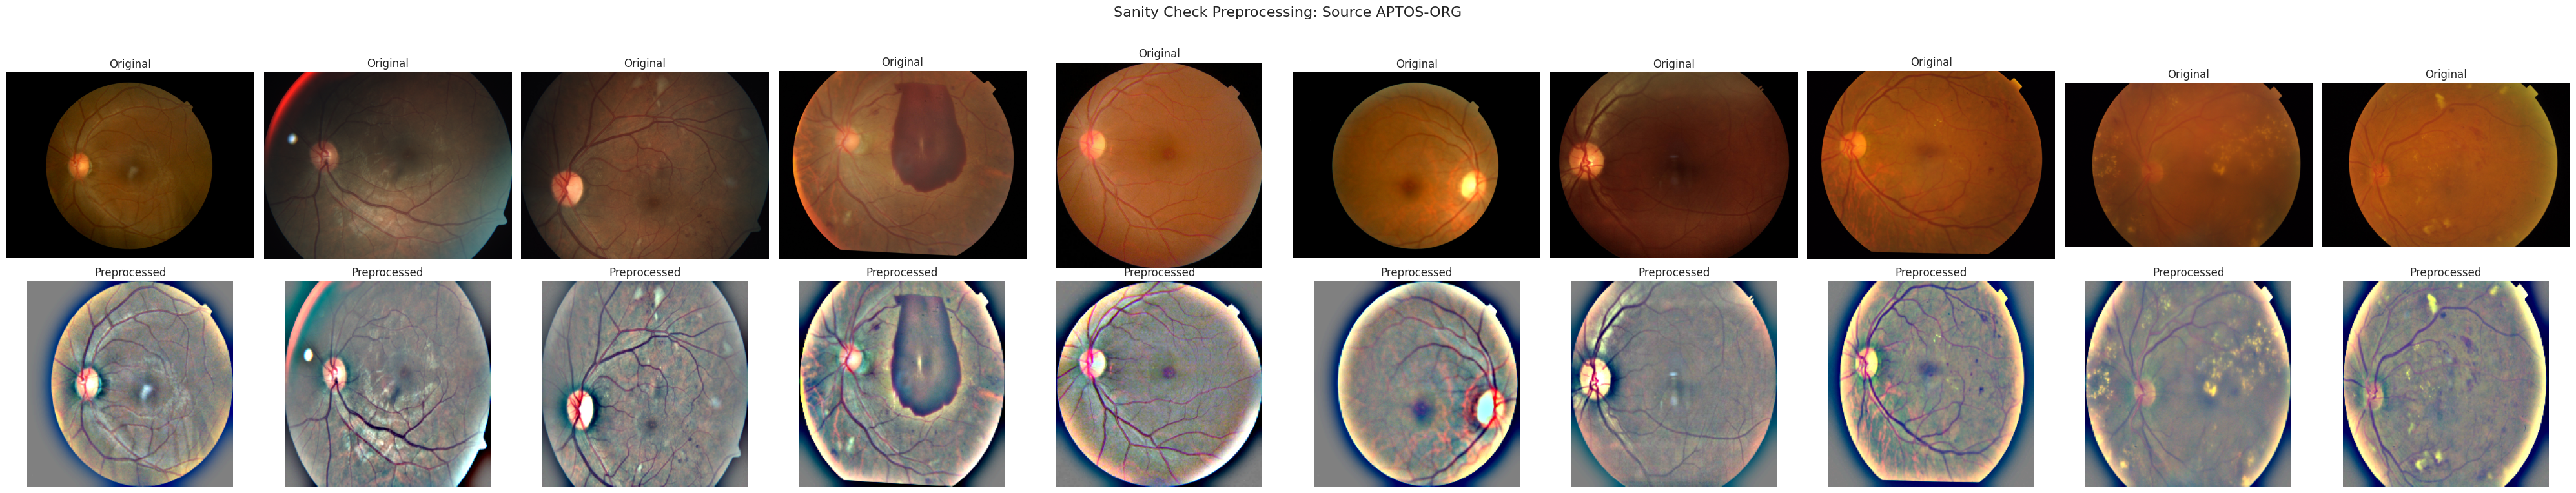

In [10]:
# @title Sanity check preprocessing on sample images

import glob


def _load_rgb(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Gagal membaca gambar: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def visualize_samples(df, source_name, num_samples=10):
    sample_paths = (
        df[df["source"] == source_name]["filepath"].head(num_samples).tolist()
    )
    if not sample_paths:
        print(f"Tidak ada sampel untuk sumber: {source_name}")
        return

    fig, axes = plt.subplots(2, len(sample_paths), figsize=(4 * len(sample_paths), 8))
    fig.suptitle(
        f"Sanity Check Preprocessing: Source {source_name.upper()}", fontsize=16
    )

    for i, p in enumerate(sample_paths):
        raw = _load_rgb(p)
        proc = preprocess_image(raw)

        # Tampilkan Raw
        axes[0, i].imshow(raw)
        axes[0, i].set_title("Original")
        axes[0, i].axis("off")

        # Tampilkan Preprocessed
        axes[1, i].imshow(proc)
        axes[1, i].set_title("Preprocessed")
        axes[1, i].axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Visualisasi untuk tiap sumber
for src in full_df["source"].unique():
    visualize_samples(full_df, src)

#STRATIFIED SPLIT & TRAIN BALANCING FUNCTION

In [11]:
def get_split(df, scenario="80:20", seed=42):
    """
    scenario ∈ {"70:30", "80:20", "90:10"} — rasio (train+val) : test
    Di dalam porsi (train+val), rasio train:val selalu 80:20, mengikuti tabel proposal:
      70:30 -> train 56% | val 14% | test 30%
      80:20 -> train 64% | val 16% | test 20%
      90:10 -> train 72% | val 18% | test 10%
    """
    trainval_frac = {"70:30": 0.70, "80:20": 0.80, "90:10": 0.90}[scenario]
    trainval_df, test_df = train_test_split(
        df, test_size=1 - trainval_frac, random_state=seed, stratify=df["label"]
    )
    train_df, val_df = train_test_split(
        trainval_df, test_size=0.20, random_state=seed, stratify=trainval_df["label"]
    )
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


# def oversample_train(df, seed=42):
#     """Oversampling data latih ke jumlah kelas mayoritas (tanpa undersampling)."""
#     counts = df["label"].value_counts()
#     max_n = counts.max()
#     parts = []
#     for label, n in counts.items():
#         df_cls = df[df["label"] == label]
#         parts.append(df_cls if n == max_n else df_cls.sample(max_n, replace=True, random_state=seed))
#     return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

#PERSIAPAN DATASET PELATIHAN

In [12]:
# @title Precompute preprocessing cache function
import hashlib

CACHE_DIR = "/content/preprocess_cache"
os.makedirs(CACHE_DIR, exist_ok=True)


def _cache_path(filepath, img_size=224):
    h = hashlib.md5(f"{filepath}_{img_size}".encode()).hexdigest()
    return os.path.join(CACHE_DIR, f"{h}.png")


def precompute_cache(df, img_size=224):
    """Jalankan preprocess_image SEKALI utk tiap gambar unik, simpan hasilnya sbg
    PNG 224x224 di CACHE_DIR. Idempotent: kalau file cache sudah ada, dilewati
    (aman dipanggil ulang / lanjut kalau sesi Colab keputus di tengah jalan)."""
    n_done, n_skip, n_fail = 0, 0, 0
    for fp in tqdm(df["filepath"].unique(), desc="Precompute cache"):
        cpath = _cache_path(fp, img_size)
        if os.path.exists(cpath):
            n_skip += 1
            continue
        img_bgr = cv2.imread(fp)
        if img_bgr is None:
            print(f"WARNING: gagal load {fp}, dilewati")
            n_fail += 1
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_proc = preprocess_image(img_rgb, img_size=img_size)
        cv2.imwrite(cpath, cv2.cvtColor(img_proc, cv2.COLOR_RGB2BGR))
        n_done += 1
    print(
        f"Selesai: {n_done} gambar baru di-cache, {n_skip} sudah ada (skip), {n_fail} gagal."
    )

In [13]:
# @title Custom PyTorch Dataset (dgn cache preprocessing)


class DRDataset(Dataset):
    LABEL_TO_IDX = {
        "No_DR": 0,
        "Mild": 1,
        "Moderate": 2,
        "Severe": 3,
        "Proliferate_DR": 4,
    }

    def __init__(self, df, img_size=224, transform=None, use_cache=True):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.transform = transform
        self.use_cache = use_cache

    def __len__(self):
        return len(self.df)

    def _load_processed(self, filepath):
        if self.use_cache:
            cpath = _cache_path(filepath, self.img_size)
            if os.path.exists(cpath):
                img_bgr = cv2.imread(cpath)
                return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        # cache miss
        img_bgr = cv2.imread(filepath)
        if img_bgr is None:
            raise ValueError(f"Gagal membaca gambar: {filepath}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        return preprocess_image(img_rgb, img_size=self.img_size)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_proc = self._load_processed(row["filepath"])
        img_pil = Image.fromarray(img_proc)

        if self.transform is not None:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = transforms.ToTensor()(img_pil)

        label_idx = self.LABEL_TO_IDX[row["label"]]
        return img_tensor, label_idx

In [14]:
# @title Transforms (augmentasi + normalisasi)
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# augmentasi hanya untuk train; val/test hanya normalisasi
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

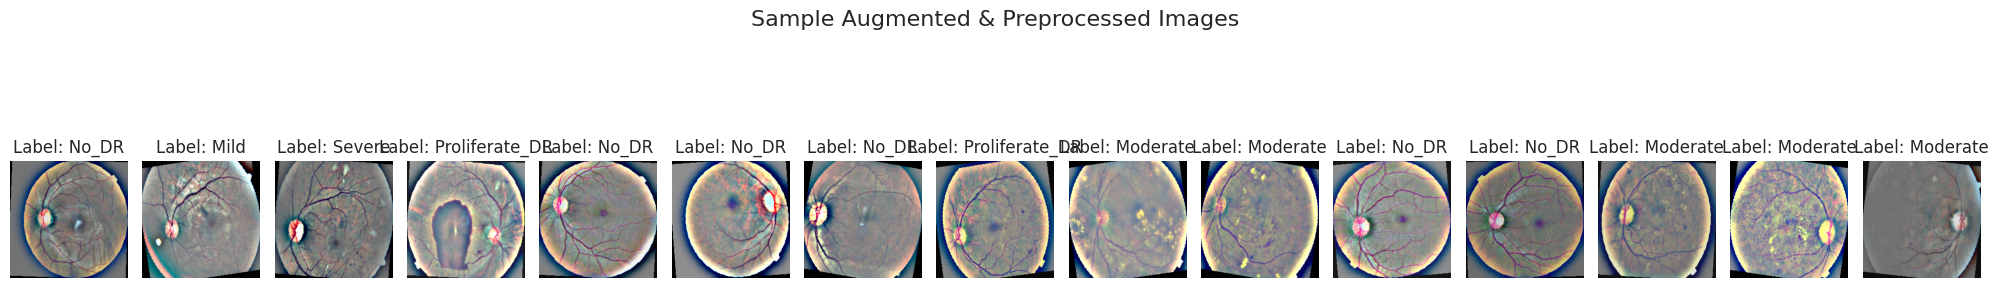

In [15]:

# Ambil satu contoh dataset dengan transform training
test_ds = DRDataset(
    full_df.head(15), img_size=IMG_SIZE, transform=train_transform, use_cache=True
)

fig, axes = plt.subplots(1, 15, figsize=(20, 4))
fig.suptitle("Sample Augmented & Preprocessed Images", fontsize=16)

for i in range(15):
    img_tensor, label_idx = test_ds[i]

    # Denormalisasi untuk visualisasi
    img = img_tensor.permute(1, 2, 0).numpy()
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(f"Label: {LABEL_NAMES[label_idx]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

#Bayesian CNN (DenseNet-121 backbone + MC Dropout)

In [16]:
# @title BCNN model builder
NUM_CLASSES = 5
DROPOUT_P = 0.3


class MCDropout(nn.Dropout):
    """
    Monte Carlo Dropout Layer:
    Memaksa fungsionalitas Dropout tetap AKTIF (training=True)
    bahkan ketika model berada dalam mode evaluasi (model.eval()).
    """

    def forward(self, x):
        return F.dropout(x, p=self.p, training=True, inplace=self.inplace)


class DenseNet121Head(nn.Module):
    """
    Set use_mc_dropout=False digunakan untuk varian "DenseNet121 CNN biasa".
    """

    def __init__(
        self,
        num_classes=5,
        hidden_dim=256,
        dropout_rate=0.4,
        use_mc_dropout=True,
        pretrained=True,
    ):
        super().__init__()
        weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.densenet121(weights=weights)
        self.features = backbone.features  # include_top=False
        in_features = backbone.classifier.in_features  # 1024

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout1 = nn.Dropout(p=dropout_rate) if use_mc_dropout else nn.Identity()
        self.bn = nn.BatchNorm1d(in_features)
        self.fc1 = nn.Linear(in_features, hidden_dim)
        self.relu = nn.ReLU(inplace=True)
        self.dropout2 = nn.Dropout(p=dropout_rate) if use_mc_dropout else nn.Identity()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=True)  # feature map akhir
        x = self.gap(x)  # GAP
        x = torch.flatten(x, 1)
        x = self.dropout1(x)
        x = self.bn(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout2(x)
        return self.fc2(x)  # Dense 5 (softmax via CrossEntropyLoss/F.softmax)


def build_model(
    model_type, num_classes=5, hidden_dim=256, dropout_rate=0.4, pretrained=True
):
    """model_type ∈ {"deterministic", "bayesian"}"""
    return DenseNet121Head(
        num_classes,
        hidden_dim,
        dropout_rate,
        use_mc_dropout=(model_type == "bayesian"),
        pretrained=pretrained,
    )

In [17]:
# @title MC Dropout Inference Functions


def enable_mc_dropout(model):
    """Mengaktifkan kembali seluruh layer Dropout saat model dalam mode eval."""
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            m.train()


def mc_dropout_predict(model, x, T=25):
    """
    Melakukan T kali forward pass Monte Carlo Dropout
    dan menghitung Predictive Entropy, Aleatoric Entropy, serta Epistemic Uncertainty (MI/BALD).
    """
    model.eval()  # Freeze BatchNorm running statistics
    enable_mc_dropout(model)  # Aktifkan khusus layer Dropout

    probs_samples = []
    with torch.no_grad():
        for _ in range(T):
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            probs_samples.append(probs)

    # Tensor shape: (T, Batch_size, Num_classes)
    probs_samples = torch.stack(probs_samples, dim=0)

    # Mean probability over T samples (Prediksi akhir)
    mean_probs = probs_samples.mean(dim=0)

    eps = 1e-12
    # Clamping probabilitas agar aman dari log(0)
    mean_probs_clamped = torch.clamp(mean_probs, eps, 1.0 - eps)
    probs_samples_clamped = torch.clamp(probs_samples, eps, 1.0 - eps)

    # 1. Total Predictive Entropy: H[P(y|x)]
    predictive_entropy = -(mean_probs_clamped * torch.log(mean_probs_clamped)).sum(
        dim=1
    )

    # 2. Aleatoric Uncertainty: E[H[P(y|x, w)]] (Rata-rata entropy per-sample)
    per_sample_entropy = -(
        probs_samples_clamped * torch.log(probs_samples_clamped)
    ).sum(dim=2)
    aleatoric_entropy = per_sample_entropy.mean(dim=0)

    # 3. Epistemic Uncertainty (BALD / Mutual Information)
    epistemic_uncertainty = torch.clamp(predictive_entropy - aleatoric_entropy, min=0.0)

    return {
        "mean_probs": mean_probs,
        "predictive_entropy": predictive_entropy,
        "aleatoric_entropy": aleatoric_entropy,
        "epistemic_uncertainty": epistemic_uncertainty,
    }

#Fungsi-fungsi Pelatihan Model

In [18]:
# @title Helper Functions untuk Training & Validasi
import os

import torch
import torch.nn as nn
from tqdm.notebook import tqdm

criterion = nn.CrossEntropyLoss()


def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="Train", leave=False)
    for imgs, labels in pbar:
        imgs, labels = (
            imgs.to(device, non_blocking=True),
            labels.to(device, non_blocking=True),
        )
        optimizer.zero_grad(set_to_none=True)

        # Mixed Precision Forward Pass
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(imgs)
            loss = criterion(logits, labels)

        # Backward Pass menggunakan GradScaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return epoch_loss, epoch_acc, epoch_qwk


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluasi deterministik untuk pemantauan validasi tiap epoch."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="Val", leave=False)
    for imgs, labels in pbar:
        imgs, labels = (
            imgs.to(device, non_blocking=True),
            labels.to(device, non_blocking=True),
        )

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(imgs)
            loss = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return epoch_loss, epoch_acc, epoch_qwk

In [19]:
# @title Helper Function untuk metrik Sensifity & Specificity
from sklearn.metrics import precision_score


def compute_sens_spec(cm):
    """Sensitivity & Specificity per kelas dari confusion matrix (one-vs-rest)."""
    n = cm.shape[0]
    total = cm.sum()
    sens, spec = np.zeros(n), np.zeros(n)
    for i in range(n):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP
        sens[i] = TP / (TP + FN) if (TP + FN) else 0.0
        spec[i] = TN / (TN + FP) if (TN + FP) else 0.0
    return sens, spec

In [25]:
# @title Fungsi Pelatihan Utama (Warm-up & Full Fine-Tuning) + Evaluasi Performa
import json

DRIVE_EXP_ROOT = "/content/drive/MyDrive/BayesianCNN/Experiments"


def run_experiment(
    df,
    model_type,
    split_scenario,
    experiment_name,
    epochs_p1=5,
    epochs_p2=45,
    patience=12,
    img_size=224,
    hidden_dim=256,
):
    print(
        f"\n{'=' * 70}\nEKSPERIMEN: {experiment_name} ({model_type}, split {split_scenario})\n{'=' * 70}"
    )

    # 0. Folder di Drive (untuk output final) + path checkpoint LOKAL (untuk selama training)
    exp_dir = os.path.join(DRIVE_EXP_ROOT, experiment_name)
    os.makedirs(exp_dir, exist_ok=True)
    ckpt_path_local = f"/content/{experiment_name}_best.pt"

    # 1. Split & balancing
    train_df, val_df, test_df = get_split(df, split_scenario)
    # train_df = oversample_train(train_df)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    # 2. Cache & dataset/loader
    precompute_cache(train_df, img_size)
    precompute_cache(val_df, img_size)
    precompute_cache(test_df, img_size)
    train_loader = DataLoader(
        DRDataset(train_df, img_size, train_transform),
        batch_size=64,
        shuffle=True,
        num_workers=0,
    )
    val_loader = DataLoader(
        DRDataset(val_df, img_size, val_transform),
        batch_size=64,
        shuffle=False,
        num_workers=0,
    )
    test_loader = DataLoader(
        DRDataset(test_df, img_size, val_transform),
        batch_size=64,
        shuffle=False,
        num_workers=0,
    )

    # 3. Model
    model = build_model(model_type, hidden_dim=hidden_dim).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_qwk": [],
        "val_loss": [],
        "val_acc": [],
        "val_qwk": [],
    }
    best_val_qwk = -1.0

    # 4. Fase 1: warm-up head (backbone frozen)
    for p in model.features.parameters():
        p.requires_grad = False
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
    )
    for epoch in range(1, epochs_p1 + 1):
        tr_loss, tr_acc, tr_qwk = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, DEVICE
        )
        v_loss, v_acc, v_qwk = evaluate(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["train_qwk"].append(tr_qwk)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)
        history["val_qwk"].append(v_qwk)
        print(
            f"[P1 {epoch:02d}/{epochs_p1}] train_loss={tr_loss:.4f} val_loss={v_loss:.4f} | train_acc={tr_acc:.4f} val_acc={v_acc:.4f} | train_qwk={tr_qwk:.4f} val_qwk={v_qwk:.4f}"
        )
        if v_qwk > best_val_qwk:
            best_val_qwk = v_qwk
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "phase": 1,
                    "val_qwk": v_qwk,
                },
                ckpt_path_local,
            )

    # 5. Fase 2: full fine-tuning
    for p in model.parameters():
        p.requires_grad = True
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-7
    )
    no_improve = 0
    for epoch in range(1, epochs_p2 + 1):
        tr_loss, tr_acc, tr_qwk = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, DEVICE
        )
        v_loss, v_acc, v_qwk = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step(v_qwk)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["train_qwk"].append(tr_qwk)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)
        history["val_qwk"].append(v_qwk)
        print(
            f"[P2 {epoch:02d}/{epochs_p2}] train_loss={tr_loss:.4f} val_loss={v_loss:.4f} | train_acc={tr_acc:.4f} val_acc={v_acc:.4f} | train_qwk={tr_qwk:.4f} val_qwk={v_qwk:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}"
        )
        if v_qwk > best_val_qwk:
            best_val_qwk = v_qwk
            no_improve = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "phase": 2,
                    "val_qwk": v_qwk,
                },
                ckpt_path_local,
            )
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[EARLY STOPPING] epoch {epoch}")
                break

    # 6. Muat checkpoint terbaik (dari lokal), evaluasi, kemudian dicopy ke Drive sekali
    ckpt = torch.load(ckpt_path_local, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(
        f"Checkpoint terbaik: epoch {ckpt['epoch']} (fase {ckpt['phase']}, val_qwk={ckpt['val_qwk']:.4f})"
    )

    ckpt_path_drive = os.path.join(exp_dir, "best_model.pt")
    shutil.copy2(ckpt_path_local, ckpt_path_drive)  # copy ke Drive
    print(f"Model terbaik disalin ke: {ckpt_path_drive}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            logits = model(imgs.to(DEVICE))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    all_preds, all_labels = np.array(all_preds), np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)
    sens, spec = compute_sens_spec(cm)
    class_names = list(DRDataset.LABEL_TO_IDX.keys())

    # Classification Report
    clf_report_text = classification_report(
        all_labels, all_preds, target_names=class_names, zero_division=0
    )
    clf_report_dict = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    # 7. Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_acc"], label="train")
    axes[0].plot(history["val_acc"], label="val")
    axes[0].set_title(f"{experiment_name} - Accuracy per Epoch")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(history["train_loss"], label="train")
    axes[1].plot(history["val_loss"], label="val")
    axes[1].set_title(f"{experiment_name} - Loss per Epoch")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(exp_dir, "accuracy_loss_curve.png"), dpi=150, bbox_inches="tight"
    )
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(f"{experiment_name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.savefig(
        os.path.join(exp_dir, "confusion_matrix.png"), dpi=150, bbox_inches="tight"
    )
    plt.show()

    # 8. history training, confusion matrix, ringkasan metrik
    pd.DataFrame(history).to_csv(os.path.join(exp_dir, "history.csv"), index=False)
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        os.path.join(exp_dir, "confusion_matrix.csv")
    )

    # Simpan Classification Report (Teks & CSV)
    with open(os.path.join(exp_dir, "classification_report.txt"), "w") as f:
        f.write(clf_report_text)

    pd.DataFrame(clf_report_dict).transpose().to_csv(
        os.path.join(exp_dir, "classification_report.csv")
    )

    metrics = {
        "experiment": experiment_name,
        "model_type": model_type,
        "split_scenario": split_scenario,
        "accuracy": acc,
        "precision_macro": prec,
        "sensitivity_macro": sens.mean(),
        "specificity_macro": spec.mean(),
        "qwk": qwk,
        "best_epoch": ckpt["epoch"],
        "best_phase": ckpt["phase"],
        "classification_report": clf_report_dict,
    }
    with open(os.path.join(exp_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    print(
        f"\n{experiment_name}: Acc={acc:.4f} | Precision(macro)={prec:.4f} | "
        f"Sensitivity(macro)={sens.mean():.4f} | Specificity(macro)={spec.mean():.4f} | QWK={qwk:.4f}"
    )

    print("=" * 30 + " Classification Report " + "=" * 30)
    print(clf_report_text)
    print("=" * 80)

    print(f"Semua output tersimpan di: {exp_dir}")

    return {
        **metrics,
        "model": model,
        "history": history,
        "confusion_matrix": cm,
        "test_loader": test_loader,
        "classification_report": clf_report_dict,
    }

#EKSPERIMEN UTAMA

In [26]:
results = []


EKSPERIMEN: APTOS-ORG_bayesian_70:30 (bayesian, split 70:30)
Train: 2050 | Val: 513 | Test: 1099


Precompute cache:   0%|          | 0/2050 [00:00<?, ?it/s]

Selesai: 0 gambar baru di-cache, 2050 sudah ada (skip), 0 gagal.


Precompute cache:   0%|          | 0/513 [00:00<?, ?it/s]

Selesai: 0 gambar baru di-cache, 513 sudah ada (skip), 0 gagal.


...

Val:   0%|          | 0/9 [00:00<?, ?it/s]

[P2 44/45] train_loss=0.4762 val_loss=0.5248 | train_acc=0.8098 val_acc=0.8051 | train_qwk=0.8669 val_qwk=0.8463 | lr=2.50e-06


Train:   0%|          | 0/33 [00:00<?, ?it/s]

Val:   0%|          | 0/9 [00:00<?, ?it/s]

[P2 45/45] train_loss=0.4692 val_loss=0.5150 | train_acc=0.8190 val_acc=0.8090 | train_qwk=0.8714 val_qwk=0.8596 | lr=1.25e-06
Checkpoint terbaik: epoch 41 (fase 2, val_qwk=0.8628)
Model terbaik disalin ke: /content/drive/MyDrive/BayesianCNN/Experiments/APTOS-ORG_bayesian_70:30/best_model.pt


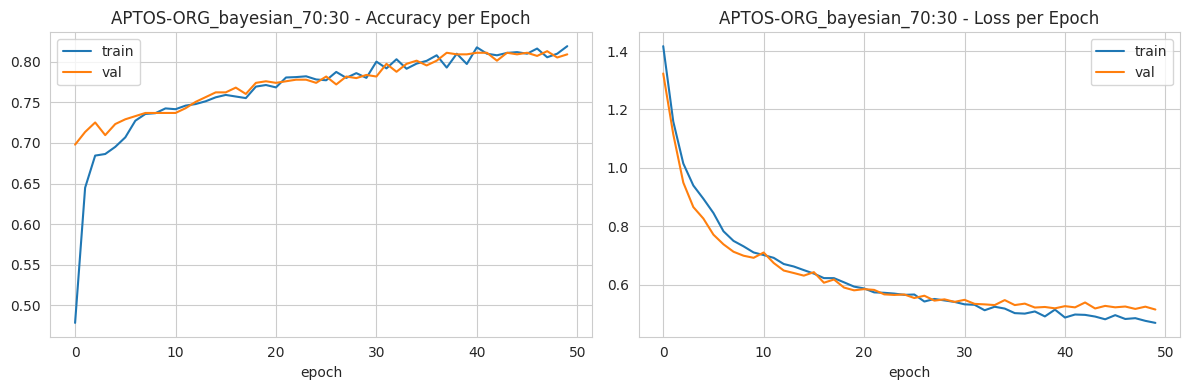

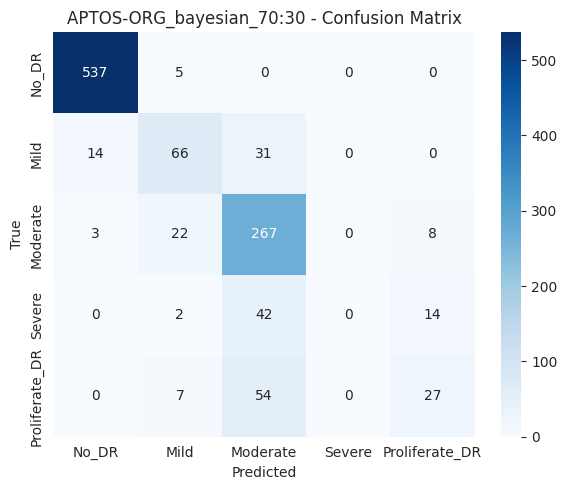


APTOS-ORG_bayesian_70:30: Acc=0.8162 | Precision(macro)=0.5690 | Sensitivity(macro)=0.5564 | Specificity(macro)=0.9505 | QWK=0.8591
============================== Classification Report ==============================
                precision    recall  f1-score   support

         No_DR       0.97      0.99      0.98       542
          Mild       0.65      0.59      0.62       111
      Moderate       0.68      0.89      0.77       300
        Severe       0.00      0.00      0.00        58
Proliferate_DR       0.55      0.31      0.39        88

      accuracy                           0.82      1099
     macro avg       0.57      0.56      0.55      1099
  weighted avg       0.77      0.82      0.79      1099

Semua output tersimpan di: /content/drive/MyDrive/BayesianCNN/Experiments/APTOS-ORG_bayesian_70:30


In [29]:
for scenario in ["70:30"]:
    for dataset_name, df in [("APTOS-ORG", aptos_org_df)]:
        for model_type in ["bayesian"]:
            results.append(
                run_experiment(
                    df, model_type, scenario, f"{dataset_name}_{model_type}_{scenario}"
                )
            )

In [30]:
results_df = pd.DataFrame(
    [
        {
            k: v
            for k, v in r.items()
            if k
            not in (
                "model",
                "history",
                "confusion_matrix",
                "test_loader",
                "classification_report",
            )
        }
        for r in results
    ]
)
results_df.to_csv(os.path.join(DRIVE_EXP_ROOT, "results_summary.csv"), index=False)
results_df.to_excel(os.path.join(DRIVE_EXP_ROOT, "results_summary.xlsx"), index=False)
results_df

,experiment,model_type,split_scenario,accuracy,precision_macro,sensitivity_macro,specificity_macro,qwk,best_epoch,best_phase
0,APTOS-ORG_bayesian_80:20,bayesian,80:20,0.834925,0.755618,0.638085,0.955867,0.891382,29,2
1,APTOS-ORG_bayesian_90:10,bayesian,90:10,0.844687,0.745916,0.653256,0.958485,0.898110,31,2
2,APTOS-ORG_bayesian_70:30,bayesian,70:30,0.816197,0.569012,0.556438,0.950467,0.859127,41,2
